# Grundgerüst Leistungsausweis
Dieses Notebook soll euch als Grundgerüst für euren Leistungsnachweis dienen. Es soll euch eine Idee/ Hilfestellung bieten, wie man einen neuen Datensatz, basierend auf einer Fragestellung, strukturiert analysieren und interpretieren kann. Wie besagt, dient das Notebook als Hilfestellung, ist jedoch keinenfalls vollständig ausgeschöpft. In diesem Sinne dürft ihr auch gerne Sachen miteinbeziehen, welche hier nicht genannt werden. 

-> Bitte schreibt die Antwort zu den jeweiligen Punkten an oberster Stelle unterhalb der Titel (so wie dies auch im Leistungsnachweisbeispiel gemacht wurde).


## Struktur
1. Fragestellung(en) und Datenbeschaffung
2. Daten laden
3. Daten vorbereiten
4. Statistik der Rohdaten (Generell im Longformat)
5. Analyse der Daten

**Wichtig:** Alle graphischen Darstellungen sollten mindestens *Titel, Ticks- und Achsenbeschriftung* beinhalten (Siehe plots im Leistungsnachweisbeispiel)

---

## 1. Fragestellung(en) und Datenbeschaffung
### 1.1 Titel: 
- Fertilitiy-rate
### 1.2 Fragestellung:
- Wie haben sich die Fruchtbarkeitsraten auf den sechs Kontinenten (Europa, Nord- und Südamerika, Asien, Afrika, Australien) seit 1950 entwickelt?
- Unterscheidet sich die Entwicklung der Fruchtbarkeitsraten zwischen Afrika und Asien seit 1970, und welcher der beiden Kontinenten zeigt stärkere Veränderungen?
### 1.3 Datenquelle(n):
- https://ourworldindata.org/grapher/children-born-per-woman?country=OWID_WRL~USA~GBR~RUS~DEU~JPN~IND~CHE

#### 1.3.1 Quellen zur Interpretation
- Chesnais, J. C. (1992). The demographic transition. Oxford University Press.
- Caldwell, J. C. (1982). Theory of fertility decline. Academic Press.
- Bongaarts, J. (2017). Africa’s unique fertility transition. Population and Development Review, 43(S1), 39–58.
- Bongaarts, J., & Watkins, S. C. (1996). Social interactions and contemporary fertility transitions. Population and Development Review, 22(4), 639–682.
- Greenhalgh, S. (2008). Just one child: Science and policy in Deng’s China. University of California Press.
- Kirk, D. (1996). Demographic transition theory. Population Studies, 50(3), 361–387.
- Lesthaeghe, R. (2010). The second demographic transition. Population and Development Review, 36(2), 211–251.
- OECD. (2023). Fertility trends. OECD Publishing.
- United Nations. (2024). World fertility report 2024. United Nations Department of Economic and Social Affairs.
- Roser, M., & Dattani, S. (2024). Fertility rate. Our World in Data.






### 1.4 Daten beschaffen und laden

In [1]:
# lade deine Bibliotheken -> Pandas, Seaborn, Matplotlib sind die wichtigsten für diese Aufgaben

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# lade hier deine Daten

data = pd.read_csv('children-born-per-woman.csv')

data.head()

,Entity,Code,Year,"Fertility rate (period), historical"
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260
3,Afghanistan,AFG,1953,7.266
4,Afghanistan,AFG,1954,7.254


## 2. Daten vorbereiten 
- Welches Format hat mein Datensatz bzw. wie sind meine Kolumnen strukturiert?
- Welches Format kann ich für welche Teilschritte verwenden (wann soll ich pivot bzw. wide format verwenden)?
- Welche Datentypen kommen in meinem Datensatz vor?

In [135]:
print(data.dtypes)

df_pivot = data.pivot(index='Entity', columns='Year', values='Fertility rate (period), historical')
df_pivot.head()

Entity                                  object
Code                                    object
Year                                     int64
Fertility rate (period), historical    float64
dtype: object


Year,1891,1892,1893,1894,1895,1896,1897,1898,1899,1900,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.770,5.652,5.542,5.433,5.327,5.238,5.145,5.039,4.932,4.840
Africa (UN),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.686,4.625,4.545,4.482,4.391,4.312,4.242,4.179,4.125,4.072
Albania,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.721,1.631,1.555,1.486,1.415,1.395,1.371,1.365,1.355,1.348
Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.084,3.091,3.091,3.090,3.019,2.997,2.940,2.870,2.817,2.766
American Samoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.852,2.780,2.699,2.598,2.494,2.404,2.360,2.327,2.305,2.286


## 3. Statistik der Rohdaten (Analyse im Long-Format)
Folgende Aussagen können über die einzelnen Spalten getroffen werden:

- Die Spalte 'Entity' enthält 255 verschiedene Gebiete.
- Die Spalte 'Code' enthält die Länderodes von 238 Gebieten. Bei 1127 Darensätzen fehlt der Ländercode.
- Die Spalte 'Year' enthält 133 Jahreszahlen zwischen 1891 und 2023. Ab 1950 sind die Daten aller Gebiete vorhanden.
- Die Spalte 'Fertility rate (period), historical' enthält 18958 Datenpunkte zur Fertilitätsrate in den jeweiligen Gebieten. Die streut zwischen 0.662 und 8.864 bei einem Durchschnitt von 3.947.





In [136]:
data.dtypes

Entity                                  object
Code                                    object
Year                                     int64
Fertility rate (period), historical    float64
dtype: object

In [137]:
# Fehlende Werte prüfen
data.isnull().sum()

Entity                                    0
Code                                   1127
Year                                      0
Fertility rate (period), historical       0
dtype: int64

### 3.1 Analyse Gebiete

In [138]:
data['Entity'].value_counts()

Entity
Sweden               133
Denmark              108
Canada               103
Spain                102
Switzerland           92
                    ... 
Western Sahara        74
Zimbabwe              74
Yemen                 74
England and Wales     12
Scotland               5
Name: count, Length: 255, dtype: int64

<Axes: title={'center': 'Anzahl Datenpunkte pro Gebiet'}, xlabel='Entity', ylabel='Anzahl Datenpunkte'>

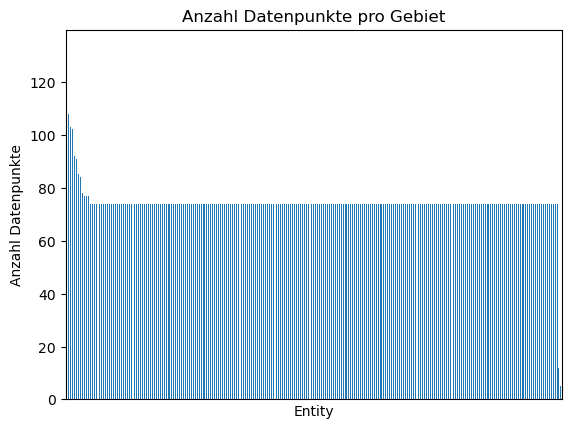

In [139]:
data['Entity'].value_counts().plot(kind='bar', 
                                 xticks=[],     # disable labels on x-axis
                                 ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Gebiet')

### 3.2 Analyse Codes

In [140]:
data['Code'].value_counts()

Code
SWE         133
DNK         108
CAN         103
ESP         102
CHE          92
           ... 
ESH          74
OWID_WRL     74
YEM          74
ZMB          74
ZWE          74
Name: count, Length: 238, dtype: int64

### 3.3 Analyse Jahr


In [141]:
data['Year'].value_counts()

Year
1950    253
1951    253
1952    253
1953    253
1954    253
       ... 
1911      1
1912      1
1913      1
1914      1
1915      1
Name: count, Length: 133, dtype: int64

In [142]:
data['Year'].min()

1891

In [143]:

data['Year'].max()

2023

<Axes: title={'center': 'Anzahl Datenpunkte pro Gebiet'}, xlabel='Year', ylabel='Anzahl Datenpunkte'>

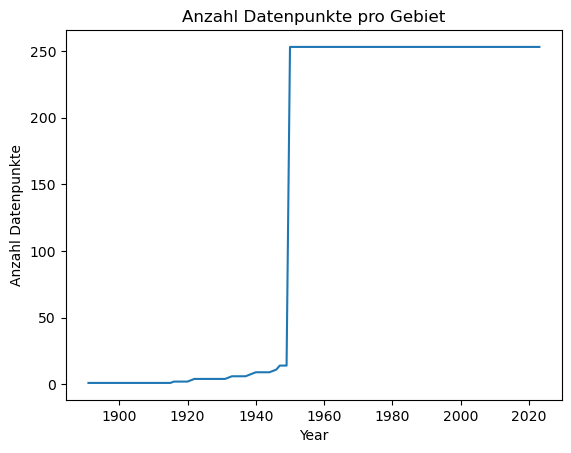

In [144]:
data['Year'].value_counts().sort_index().plot(kind='line',ylabel='Anzahl Datenpunkte', title='Anzahl Datenpunkte pro Gebiet')

### 3.3 Analyse Fertilitätsrate

In [145]:
data.describe()

,Year,"Fertility rate (period), historical"
count,18958.000000,18958.000000
mean,1985.846661,3.947225
std,22.064795,1.998850
min,1891.000000,0.662000
25%,1967.000000,2.134000
50%,1986.000000,3.481000
75%,2005.000000,5.876000
max,2023.000000,8.864000


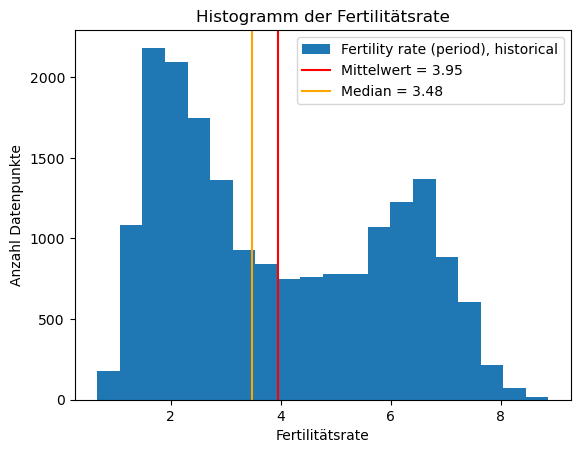

In [146]:
g = data['Fertility rate (period), historical'].plot(kind='hist', bins=20, title='Histogramm der Fertilitätsrate', 
                           xlabel='Fertilitätsrate', ylabel='Anzahl Datenpunkte')
mean = data['Fertility rate (period), historical'].mean()
g.axvline(x=data['Fertility rate (period), historical'].mean(), color='red',label=f'Mittelwert = {mean:.2f}')  # rote Linie bei Mittelwert

median = data['Fertility rate (period), historical'].median()
g.axvline(x=data['Fertility rate (period), historical'].median(), color='orange',label=  f'Median = {median:.2f}')  # orange Linie bei Median

g.legend()

## 4. Analyse 

### Vorgehen
- Spezifische Untersuchung der Fragestellung (Berechnungen)
- Visualisieren der Resultate: Verwendet Achsenbeschriftung und überlegt euch, welche Art von Darstellung sinnvoll ist (Kuchen-, Säulen, Liniendiagramm; 2 y-Achsen?)
- Beschreiben der Beobachtungen
- Interpretation der Resultate (Hypothesen zu den Resultaten)
- Untermauern der Interpretation mittels Hinweise zur Literatur (Mögliche Zusammenhänge aufzeigen).

### Beobachtungen
Die Fruchtbarkeitsraten zeigen auf allen sechs Kontinenten einen langfristigen Rückgang. Ab etwa 1960 sinken die Werte kontinuierlich. Afrika weist über den gesamten Zeitraum hinweg die höchsten Fruchtbarkeitsraten auf, während Europa seit 1950 die niedrigsten Werte zeigt. Die Fruchtbarkeitsrate in Asien ist seit den 1970er Jahren stärker gesunken als in Afrika. Lateinamerika zeigt eine ähnliche Entwicklung wie Asien, während Nordamerika und Australien meist zwischen Europa und Asien liegen.


### Interpretation
Interpretation der Entwicklung der Fruchtbarkeitsraten

Die Analyse der Fruchtbarkeitsraten auf den sechs Kontinenten zeigt einen langfristigen globalen Rückgang der Geburtenraten. Bereits ab dem frühen 20. Jahrhundert ist ein Abwärtstrend erkennbar, der insbesondere während der beiden Weltkriege (1914–1918 und 1939–1945) deutlich verstärkt wurde. In diesen Zeiträumen führten politische Unsicherheit, wirtschaftliche Notlagen, erhöhte Sterblichkeit sowie die Abwesenheit vieler Männer zu einem Rückgang der Geburtenzahlen, da Familiengründungen aufgeschoben oder vermieden wurden (Chesnais, 1992; Kirk, 1996).

Nach dem Zweiten Weltkrieg ist in vielen Regionen um das Jahr 1950 ein kurzfristiger Anstieg der Geburtenraten zu beobachten, der unter anderem auf den sogenannten Babyboom zurückzuführen ist. Dieser Effekt war jedoch zeitlich begrenzt. Ab den 1960er Jahren sinken die Fruchtbarkeitsraten auf allen Kontinenten kontinuierlich, was im Zusammenhang mit dem demografischen Übergang steht (United Nations, 2024; Our World in Data, 2024).

Afrika weist über den gesamten Beobachtungszeitraum hinweg die höchsten Fruchtbarkeitsraten auf, auch wenn in den letzten Jahrzehnten ein Rückgang erkennbar ist. Gründe hierfür sind unter anderem ein eingeschränkter Zugang zu Bildung, insbesondere für Frauen, eine begrenzte Verfügbarkeit von Verhütungsmitteln sowie eine weiterhin hohe Kindersterblichkeit. Zudem spielen sozioökonomische Faktoren eine Rolle, da Kinder in vielen Regionen Afrikas als Absicherung im Alter dienen und große Familien traditionell als ökonomisch sinnvoll gelten (Caldwell, 1982; Bongaarts, 2017; United Nations, 2024).

Im Vergleich dazu zeigt Asien seit den 1970er Jahren einen deutlich stärkeren Rückgang der Fruchtbarkeitsraten. Diese Entwicklung ist unter anderem auf eine frühere Industrialisierung, staatliche Programme zur Geburtenkontrolle in einzelnen Ländern sowie einen starken Anstieg der Schulbildung und Erwerbstätigkeit von Frauen zurückzuführen. Eine höhere Bildung führt zu einem späteren Beginn der Familiengründung und insgesamt zu einer geringeren Kinderzahl pro Frau (Bongaarts & Watkins, 1996; Greenhalgh, 2008; United Nations, 2024).

Europa weist seit 1950 durchgehend die niedrigsten Fruchtbarkeitsraten auf. Auch Nordamerika und Australien bewegen sich auf einem niedrigen Niveau und liegen meist zwischen Europa und Asien beziehungsweise Südamerika. In diesen Regionen führten frühe Industrialisierung, umfassende soziale Sicherungssysteme und ein ausgeprägter Wertewandel dazu, dass Kinder nicht mehr als wirtschaftliche Notwendigkeit betrachtet werden.  (Lesthaeghe, 2010; OECD, 2023; United Nations, 2024).

Lateinamerika zeigt eine Entwicklung, die jener Asiens ähnelt. Auch hier kam es seit der zweiten Hälfte des 20. Jahrhunderts zu einem raschen Rückgang der Fruchtbarkeitsraten, was auf verbesserte Bildung, Urbanisierung und einen erweiterten Zugang zu Familienplanung zurückzuführen ist (United Nations, 2024; Our World in Data, 2024). Insgesamt bestätigen die Ergebnisse, dass der Rückgang der Fruchtbarkeitsraten eng mit wirtschaftlicher Entwicklung, Bildung, gesellschaftlichem Wandel und staatlichen Rahmenbedingungen verknüpft ist.

### Berechnung und Visualisierung

#### Zeitliche Entwicklung des globalen Durchschnitts


In [147]:
# Zeitliche Entwicklung - Globaler Durchschnitt
global_avg = data.groupby('Year')['Fertility rate (period), historical'].mean()

global_avg.describe()

count    133.000000
mean       3.615290
std        0.971088
min        2.123750
25%        2.865826
50%        3.401000
75%        4.142000
max        5.397589
Name: Fertility rate (period), historical, dtype: float64

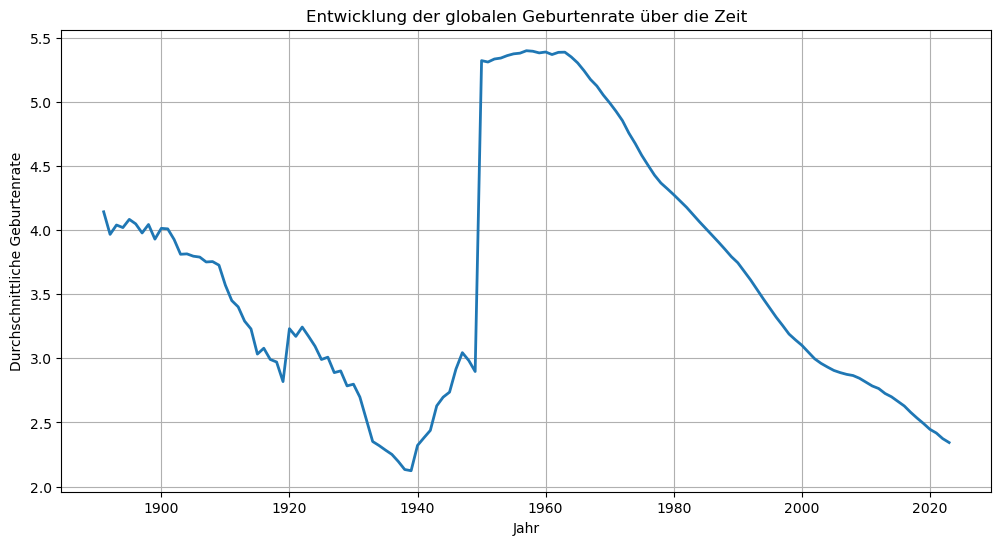

In [148]:
plt.figure(figsize=(12,6))
plt.plot(global_avg.index, global_avg.values, linewidth=2)
plt.xlabel('Jahr')
plt.ylabel('Durchschnittliche Geburtenrate')
plt.title('Entwicklung der globalen Geburtenrate über die Zeit')
plt.grid(True)
plt.show()

#### Zeitliche Entwicklung der Kontinente

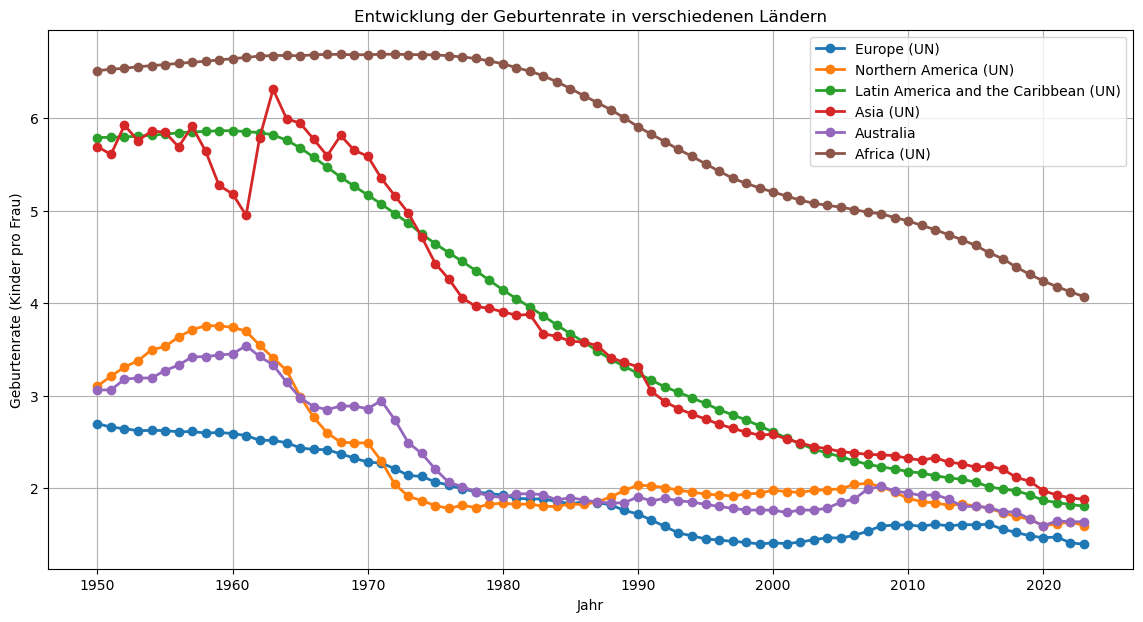

In [149]:
# Vergleich ausgewählter Länder über Zeit
countries = ['Europe (UN)', 'Northern America (UN)', 'Latin America and the Caribbean (UN)', 'Asia (UN)', 'Australia', 'Africa (UN)']

plt.figure(figsize=(14,7))
for country in countries:
    country_data = data[data['Entity'] == country]
    plt.plot(country_data['Year'], 
             country_data['Fertility rate (period), historical'], 
             marker='o', label=country, linewidth=2)

plt.xlabel('Jahr')
plt.ylabel('Geburtenrate (Kinder pro Frau)')
plt.title('Entwicklung der Geburtenrate in verschiedenen Ländern')
plt.legend()
plt.grid(True)
plt.show()

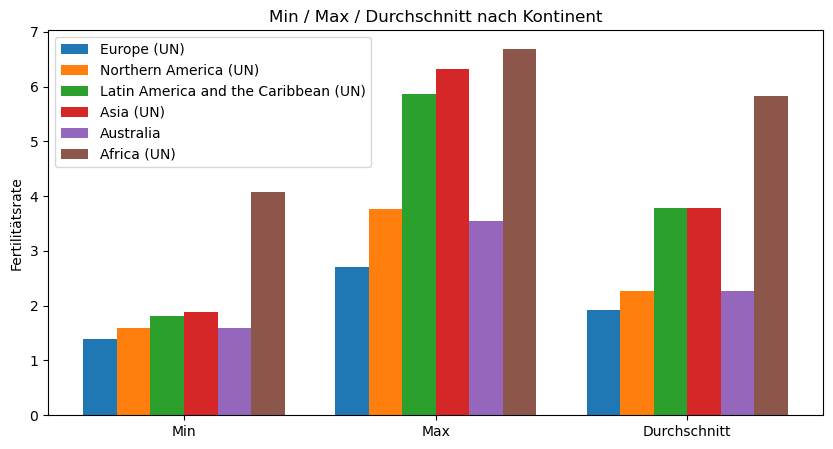

In [150]:
# Vergleich Miniumum/Maximum/Durchschnitt
labels = ['Min', 'Max', 'Durchschnitt']
x = np.arange(len(labels))
width = 0.8 / len(countries)   # Balkenbreite

plt.figure(figsize=(10, 5))

for i, country in enumerate(countries):
    country_data = data[data['Entity'] == country]
    y_values = [
        country_data['Fertility rate (period), historical'].min(),
        country_data['Fertility rate (period), historical'].max(),
        country_data['Fertility rate (period), historical'].mean()
    ]

    plt.bar(x + i * width, y_values, width=width, label=country)

plt.xticks(x + width * (len(countries) - 1) / 2, labels)
plt.ylabel('Fertilitätsrate')
plt.title('Min / Max / Durchschnitt nach Kontinent')
plt.legend()
plt.show()

<Axes: title={'center': 'Differenzen der Fertilitätsrate zwischen 1950 und 2023'}, ylabel='Entity'>

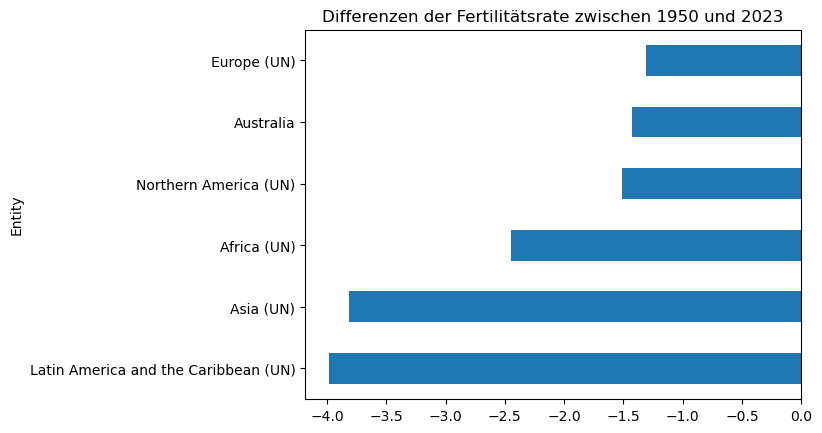

In [151]:
# Vergleich Differenz 1950 zu 2023
diffs = df_pivot[2023]-df_pivot[1950]   # Differenz zwischen 2021 und 2011
diffs = diffs.loc[countries].sort_values().dropna()  # sortieren nach Differenz und NaN-Werte entfernen
diffs.plot(kind='barh', title='Differenzen der Fertilitätsrate zwischen 1950 und 2023')

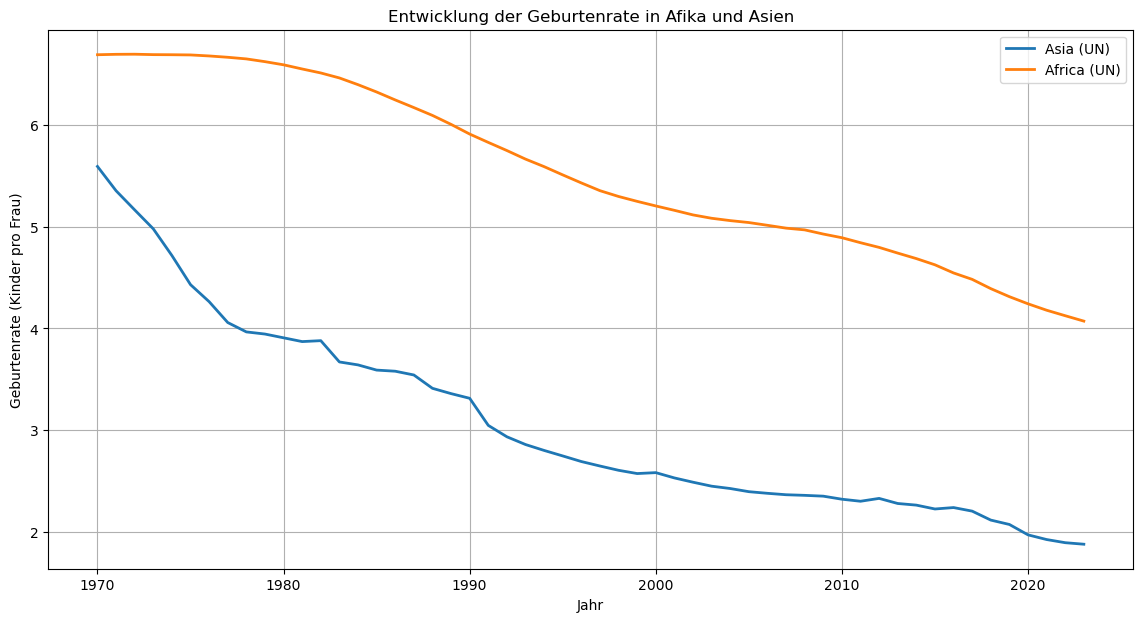

In [153]:


# Vergleich Asien und Afrika

countries_AA = ['Asia (UN)', 'Africa (UN)']

plt.figure(figsize=(14,7))
for country in countries_AA:
    country_data = data[(data['Entity'] == country) & (data['Year']>=1970)]
    plt.plot(country_data['Year'], 
             country_data['Fertility rate (period), historical'], label=country, linewidth=2)


plt.xlabel('Jahr')
plt.ylabel('Geburtenrate (Kinder pro Frau)')
plt.title('Entwicklung der Geburtenrate in Afika und Asien')
plt.legend()
plt.grid(True)
plt.show()



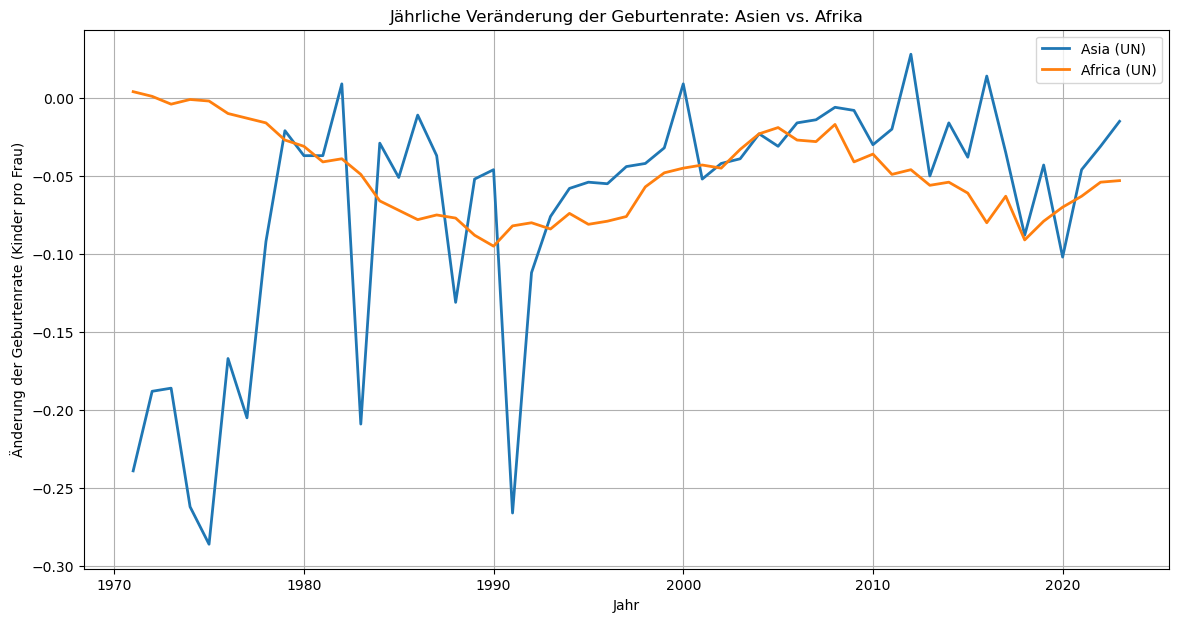

In [154]:

# Vergleich Ableitung

plt.figure(figsize=(14,7))

for country in countries_AA:
    country_data = data[
        (data['Entity'] == country) & (data['Year'] >= 1970)
    ].copy()

    diff = country_data['Fertility rate (period), historical'].diff()

    plt.plot(
        country_data['Year'],
        diff,
        label=country,
        linewidth=2
    )

plt.xlabel('Jahr')
plt.ylabel('Änderung der Geburtenrate (Kinder pro Frau)')
plt.title('Jährliche Veränderung der Geburtenrate: Asien vs. Afrika')
plt.legend()
plt.grid(True)
plt.show()

<Axes: title={'center': 'Differenzen der Fertilitätsrate zwischen 1970 und 2023'}, ylabel='Entity'>

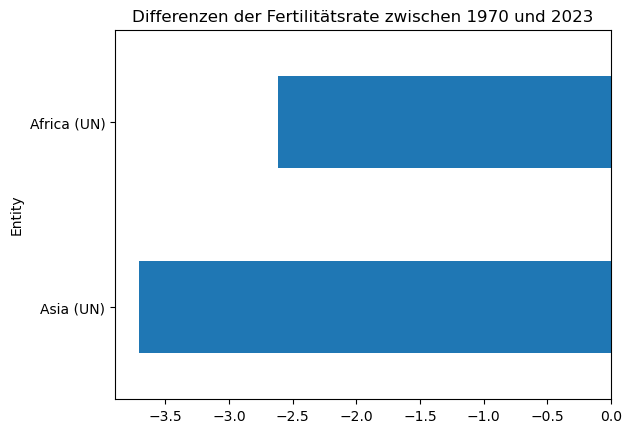

In [155]:
# Vergleich Differenz 1970 zu 2023
diffs = df_pivot[2023]-df_pivot[1970]   # Differenz zwischen 2021 und 2011
diffs = diffs.loc[countries_AA].sort_values().dropna()  # sortieren nach Differenz und NaN-Werte entfernen
diffs.plot(kind='barh', title='Differenzen der Fertilitätsrate zwischen 1970 und 2023')